Cell 1 — Import & Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/india_house_price.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Shape: (13320, 9)

Columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Missing values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


Cell 2 — Data Cleaning

In [4]:
# 1. Unnecessary columns drop karo
df.drop(['area_type', 'availability', 'society'], axis=1, inplace=True)

# 2. Missing values hatao
df.dropna(inplace=True)

# 3. size column → sirf number nikalo  "2 BHK" → 2
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]) if str(x).split(' ')[0].isdigit() else np.nan)
df.drop('size', axis=1, inplace=True)
df.dropna(subset=['bhk'], inplace=True)
df['bhk'] = df['bhk'].astype(int)

# 4. total_sqft — range handle karo "1000-1200" → 1100
def convert_sqft(x):
    try:
        if '-' in str(x):
            parts = str(x).split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        return float(x)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df.dropna(subset=['total_sqft'], inplace=True)

print("After cleaning shape:", df.shape)
print(df.head())

After cleaning shape: (12668, 6)
                   location  total_sqft  bath  balcony   price  bhk
0  Electronic City Phase II      1056.0   2.0      1.0   39.07    2
1          Chikka Tirupathi      2600.0   5.0      3.0  120.00    4
2               Uttarahalli      1440.0   2.0      3.0   62.00    3
3        Lingadheeranahalli      1521.0   3.0      1.0   95.00    3
4                  Kothanur      1200.0   2.0      1.0   51.00    2


Cell 3 — Outlier Remove karo

In [5]:
# price per sqft feature banao (outlier detection ke liye)
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

# Location wise mean/std se outliers hatao
def remove_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        gen_df = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, gen_df], ignore_index=True)
    return df_out

df = remove_outliers(df)

# BHK anomaly — 2 BHK wala 3 BHK se zyada expensive nahi hona chahiye same location mein
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {'mean': np.mean(bhk_df['price_per_sqft']), 'count': bhk_df.shape[0]}
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices,
                    bhk_df[bhk_df['price_per_sqft'] < stats['mean']].index.values)
    return df.drop(exclude_indices, axis='index')

print("Final shape:", df.shape)

Final shape: (9515, 7)


Cell 4 — Location Encoding & Save

In [6]:
# Rare locations → "other" kar do (200 se kam listings wali)
location_stats = df['location'].value_counts()
rare_locations = location_stats[location_stats <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['location_enc'] = le.fit_transform(df['location'])

# joblib se encoder save karo (API mein use hoga)
import joblib
joblib.dump(le, '../data/processed/location_encoder.pkl')

# Final dataframe
df_model = df[['location_enc', 'total_sqft', 'bath', 'balcony', 'bhk', 'price']]
df_model.to_csv('../data/processed/clean_data.csv', index=False)

print("Saved! Final columns:", df_model.columns.tolist())
print(df_model.describe())

Saved! Final columns: ['location_enc', 'total_sqft', 'bath', 'balcony', 'bhk', 'price']
       location_enc   total_sqft         bath      balcony          bhk  \
count   9515.000000   9515.00000  9515.000000  9515.000000  9515.000000   
mean     118.227325   1460.87409     2.479453     1.588124     2.591382   
std       58.718146    797.39958     0.993289     0.798283     0.940934   
min        0.000000     11.00000     1.000000     0.000000     1.000000   
25%       69.000000   1100.00000     2.000000     1.000000     2.000000   
50%      130.000000   1262.00000     2.000000     2.000000     2.000000   
75%      178.000000   1610.00000     3.000000     2.000000     3.000000   
max      183.000000  30400.00000    10.000000     3.000000    12.000000   

             price  
count  9515.000000  
mean     91.993916  
std      97.538312  
min       8.000000  
25%      48.950000  
50%      67.000000  
75%     100.000000  
max    2912.000000  


Cell 5 — Quick Visualization (optional but useful)

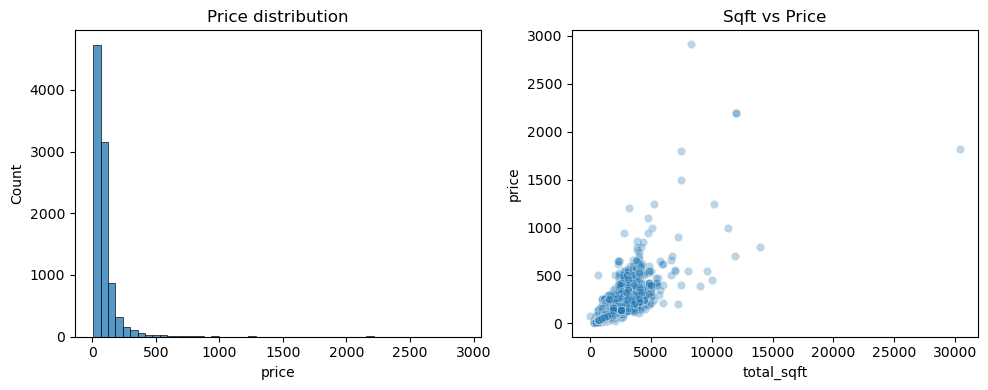

In [7]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_model['price'], bins=50)
plt.title('Price distribution')

plt.subplot(1,2,2)
sns.scatterplot(x='total_sqft', y='price', data=df_model, alpha=0.3)
plt.title('Sqft vs Price')
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import os

files = {
    'Bangalore': '../data/raw/Bangalore.csv',
    'Chennai':   '../data/raw/Chennai.csv',
    'Delhi':     '../data/raw/Delhi.csv',
    'Hyderabad': '../data/raw/Hyderabad.csv',
    'Kolkata':   '../data/raw/Kolkata.csv',
    'Mumbai':    '../data/raw/Mumbai.csv',
    'India2':    '../data/raw/house_price_india2.csv',
}

for name, path in files.items():
    df = pd.read_csv(path)
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(2))
    print()

=== Bangalore ===
Shape: (6207, 40)
Columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator']
      Price  Area                    Location  No. of Bedrooms  Resale  \
0  30000000  3340            JP Nagar Phase 1                4       0   
1   7888000  1045  Dasarahalli on Tumkur Road                2       0   

   MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  \
0                 1          1             1                  1             1   
1      